# 测试报错信息


## 调查什么图报错了，所以batch size为1

In [1]:
import argparse
from tqdm import tqdm
import dgl
import torch
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool

def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )


def train(dataset, model, prog_args, id_card_protein):
    """
    training function
    """
    dataloader = dataset

    if prog_args.cuda > 0:
        torch.cuda.set_device(0)
    
    for epoch in range(prog_args.epoch):
        model.train()
        print("\nEPOCH ###### {} ######".format(epoch))
        for batch_idx, (batch_graph, graph_labels) in tqdm(enumerate(dataloader), total=len(dataloader)):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()

            model.zero_grad()
            # ypred = model(batch_graph)
            try:
                ypred = model(batch_graph)
            except:
                temp = batch_graph
                protein_temp_id_card = ''
                protein_temp_id_card = protein_temp_id_card + "{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][0][0]), 5),
                                                                                                                                     round(float(temp.ndata['feat'][0][1]), 5),
                                                                                                                                     round(float(temp.ndata['feat'][0][2]), 5),
                                                                                                                                     round(float(temp.ndata['feat'][0][3]), 5),
                                                                                                                                     round(float(temp.ndata['feat'][0][4]), 5),
                                                                                                                                     round(float(temp.ndata['feat'][0][5]), 5),
                                                                                                                                     round(float(temp.ndata['feat'][0][6]), 5))
                protein_temp_id_card = protein_temp_id_card + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][1][0]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][1][1]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][1][2]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][1][3]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][1][4]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][1][5]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][1][6]), 5))
                protein_temp_id_card = protein_temp_id_card + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][2][0]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][2][1]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][2][2]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][2][3]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][2][4]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][2][5]), 5),
                                                                                                                                        round(float(temp.ndata['feat'][2][6]), 5))
                print('This is the protein name ==========', id_card_protein[protein_temp_id_card])
                continue
        torch.cuda.empty_cache()
        break
    return 'Trian successfully'


/home/admin123/software/anaconda3/envs/dgl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sample_redies_udp = 10.0
sample_redies_sugar = 10.0

global_train_time_per_epoch = []

print("{:=^100}".format('prog_args'))
global_train_time_per_epoch = []
prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1e-4, clip=1.0,
                               batch_size=48, epoch=500, train_ratio=0.7, test_ratio=0.1, n_worker=2, gc_per_block=3,
                               dropout=0.20, method="diffpool", bn=True, bias=True, save_dir="./model_param",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)
print(prog_args)

print("{:=^100}".format('加载数据'))
dataset_train = tu.RhaFinderDataset(name="Rha_Finder",
                                    raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train/')
dataset_test = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/test/')
dataset_realtest = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)
realtest_dataloader = prepare_data(dataset_realtest, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    "meanpool",
    assign_dim,
    prog_args.pool_ratio,
)

print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

=============================================prog_args==============================================
Namespace(dataset='udp10.0_sugar10.0', pool_ratio=0.1, num_pool=1, cuda=1, lr=0.0001, clip=1.0, batch_size=48, epoch=500, train_ratio=0.7, test_ratio=0.1, n_worker=2, gc_per_block=3, dropout=0.2, method='diffpool', bn=True, bias=True, save_dir='./model_param', load_epoch=-1, data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64)
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 1129
number of graphs is 12085
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 112
model init finished
MODEL::::::: diffpool


In [5]:
# train_dataloader  test_dataloader  realtest_dataloader

id_card_protein = {}
with open(f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/Predict_correspond_information.txt', 'r')as f:
    for dd in f.readlines():
        dd = dd.split('\n')[0].split('===')
        id_card_protein[dd[1]] = dd[0]

logger = train(
    realtest_dataloader, model, prog_args, id_card_protein
)

print("Ending!!!")


EPOCH ###### 0 ######


100%|██████████| 11/11 [00:03<00:00,  3.32it/s]

Ending!!!


# 超参数调整

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
# from torch.optim.lr_scheduler import LambdaLR

def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )


def train(dataset, model, prog_args, val_dataset=None, checkpoint=None):
    """
    training function
    """
    liveloss = PlotLosses()

    # 初始化模型存储路径
    if not os.path.exists(prog_args.save_dir + "/" + prog_args.dataset):
        os.makedirs(prog_args.save_dir + "/" + prog_args.dataset)
    elif checkpoint is None:
        shutil.rmtree(prog_args.save_dir + "/" + prog_args.dataset)
        os.makedirs(prog_args.save_dir + "/" + prog_args.dataset)

    f_train_log = open(prog_args.save_dir + "/" + prog_args.dataset + "/train_log.csv", 'w')
    f_train_log.write("{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}\n".format('epoch', 'accuracy', 'val_accuracy', 'F1 score', 'val_F1 score',
                                                                                                                                    'Class 1 F1 score', 'val_Class 1 F1 score',
                                                                                                                                    'Class 2 F1 score', 'val_Class 2 F1 score',
                                                                                                                                    'Class 3 F1 score', 'val_Class 3 F1 score',
                                                                                                                                    'Class 4 F1 score', 'val_Class 4 F1 score',
                                                                                                                                    'Class 5 F1 score', 'val_Class 5 F1 score',
                                                                                                                                    'Class 6 F1 score', 'val_Class 6 F1 score',
                                                                                                                                    'Class 7 F1 score', 'val_Class 7 F1 score',
                                                                                                                                    'Class 8 F1 score', 'val_Class 8 F1 score',
                                                                                                                                    'Class 9 F1 score', 'val_Class 9 F1 score',
                                                                                                                                    'Class 10 F1 score', 'val_Class 10 F1 score'))

    dir = prog_args.save_dir + "/" + prog_args.dataset
    if not os.path.exists(dir):
        os.makedirs(dir)
    dataloader = dataset
    # optimizer = torch.optim.Adam(
    #     filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr
    # )
    # optimizer = torch.optim.SGD(
    #     filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr, momentum=0.5
    # )
    # optimizer = torch.optim.RMSprop(filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr)
    # optimizer = torch.optim.Adagrad(filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr)  # 初始化优化器
    # optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr)  # 初始化优化器
    optimizer = torch.optim.Adadelta(filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr)  # 初始化优化器
    start_epoch = None
    if checkpoint is not None:
        start_epoch = checkpoint['epoch'] + 1
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # lr_lambda = lambda epoch: 1.0 if epoch < 5 else 0.1  # 前5个epoch保持lr=0.01，后续降为0.001
    # scheduler = LambdaLR(optimizer, lr_lambda)

    if prog_args.cuda > 0:
        torch.cuda.set_device(0)
    
    if start_epoch is not None:
        start_epoch = start_epoch
    else:
        start_epoch = 0
    for epoch in range(start_epoch, prog_args.epoch):
        train_pred_indi = torch.tensor([], device='cuda')
        train_label_indi = torch.tensor([], device='cuda')
        begin_time = time.time()
        model.train()
        accum_correct = 0
        total = 0
        print("\nEPOCH ###### {} ######".format(epoch))
        computation_time = 0.0
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()

            model.zero_grad()
            compute_start = time.time()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            train_pred_indi = torch.cat((train_pred_indi, indi), dim=0)
            train_label_indi = torch.cat((train_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels).item()
            accum_correct += correct
            total += graph_labels.size()[0]
            loss = model.loss(ypred, graph_labels)
            # train_loss_plot = loss.cpu().detach().numpy()
            loss.backward()
            batch_compute_time = time.time() - compute_start
            computation_time += batch_compute_time
            # 计算裁剪后的梯度范数（手动）
            total_norm_after = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm_after += p.grad.data.norm(2).item() ** 2
            total_norm_after = total_norm_after ** 0.5
            print("裁剪前的梯度范数:", total_norm_after)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
            # 计算裁剪后的梯度范数（手动）
            total_norm_after = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm_after += p.grad.data.norm(2).item() ** 2
            total_norm_after = total_norm_after ** 0.5
            print("裁剪前的梯度范数:", total_norm_after)
            optimizer.step()
        # scheduler.step()
        train_f1_score = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average='macro')
        train_f1_score_class_1, train_f1_score_class_2, train_f1_score_class_3, train_f1_score_class_4, train_f1_score_class_5, train_f1_score_class_6,train_f1_score_class_7, train_f1_score_class_8, train_f1_score_class_9, train_f1_score_class_10 = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average=None)

        train_accu = accum_correct / total

        elapsed_time = time.time() - begin_time

        if val_dataset is not None:
            result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = evaluate(val_dataset, model, prog_args)
            print("validation  accuracy {:.2f}%".format(result * 100))
            if prog_args.save_dir is not None:
                torch.save(
                    model.state_dict(),
                    prog_args.save_dir
                    + "/"
                    + prog_args.dataset
                    + "/model.iter-"
                    + "{:04d}".format(epoch)
                )
                checkpoint = {"optimizer_state_dict": optimizer.state_dict(), "epoch": epoch}
                torch.save(
                    checkpoint,
                    prog_args.save_dir
                    + "/"
                    + prog_args.dataset
                    + "/optimizer.iter-"
                    + "{:04d}".format(epoch)
                )


            f_train_log.write("{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {},\n".format(epoch, train_accu * 100, result * 100, train_f1_score, val_f1_score,
                                                                                                                                             train_f1_score_class_1, val_f1_score_class_1,
                                                                                                                                             train_f1_score_class_2, val_f1_score_class_2,
                                                                                                                                             train_f1_score_class_3, val_f1_score_class_3,
                                                                                                                                             train_f1_score_class_4, val_f1_score_class_4,
                                                                                                                                             train_f1_score_class_5, val_f1_score_class_5,
                                                                                                                                             train_f1_score_class_6, val_f1_score_class_6,
                                                                                                                                             train_f1_score_class_7, val_f1_score_class_7,
                                                                                                                                             train_f1_score_class_8, val_f1_score_class_8,
                                                                                                                                             train_f1_score_class_9, val_f1_score_class_9,
                                                                                                                                             train_f1_score_class_10, val_f1_score_class_10))
            logs = {} # 实时绘制Loss
            logs['accuracy'] = train_accu * 100
            logs['val_accuracy'] = result * 100
            logs['F1 score'] = train_f1_score
            logs['val_F1 score'] = val_f1_score
            liveloss.update(logs)
            liveloss.send()

            print("train accuracy for this epoch {} is {:.2f}%".format(epoch, train_accu * 100))
            print("loss {:.4f} with epoch time {:.4f} s & computation time {:.4f} s ".format(loss.item(), elapsed_time, computation_time))

        torch.cuda.empty_cache()
    f_train_log.close()
    return 'Trian successfully'


def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda:0')
        val_label_indi = torch.tensor([], device='cuda:0')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10



/home/admin123/software/anaconda3/envs/dgl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sample_redies_udp = 6.0
sample_redies_sugar = 6.0

print("{:=^100}".format('prog_args'))
# 尝试
prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=48, epoch=300, n_worker=10, gc_per_block=3, aggregator_type="meanpool", activation = F.relu,
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./model_param_998",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)
print(prog_args)

print("{:=^100}".format('加载数据'))
dataset_train = tu.RhaFinderDataset(name="Rha_Finder",
                                    raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train/')
dataset_test = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/test/')
dataset_realtest = tu.RhaFinderDataset(name="Rha_Finder",
                                       raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)
realtest_dataloader = prepare_data(dataset_realtest, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
input_dim_realtest, label_dim_realtest, max_num_node_realtest = dataset_realtest.statistics()
max_num_node = max([max_num_node_train, max_num_node_test, max_num_node_realtest])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = prog_args.activation

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
)

checkpoint = None
if prog_args.load_epoch >= 0 and prog_args.save_dir is not None: # 加载模型权重
    if prog_args.cuda > 0:
        torch.cuda.set_device(0)
    if prog_args.cuda:
        model = model.cuda()
    for epoch in range(1):
        model.train()
        print("\nGenerate model param ###### ######")
        for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            model.zero_grad()
            ypred = model(batch_graph)
        torch.cuda.empty_cache()

    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(prog_args.load_epoch)
        )
    )
    checkpoint = torch.load(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/optimizer.iter-"
            + "{:04d}".format(prog_args.load_epoch)
        )
    )
    print("model init finished")
    print("MODEL:::::::", prog_args.method)
else:
    print("model init finished")
    print("MODEL:::::::", prog_args.method)
    if prog_args.cuda:
        model = model.cuda()

=============================================prog_args==============================================
Namespace(dataset='udp6.0_sugar6.0', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf, batch_size=48, epoch=300, n_worker=10, gc_per_block=3, aggregator_type='meanpool', activation=<function relu at 0x7f4a1aad3160>, dropout=0.0, method='diffpool', bn=True, bias=True, save_dir='./model_param_998', load_epoch=-1, data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64)
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 537
number of graphs is 12085
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 53
model init finished
MODEL::::::: diffpool


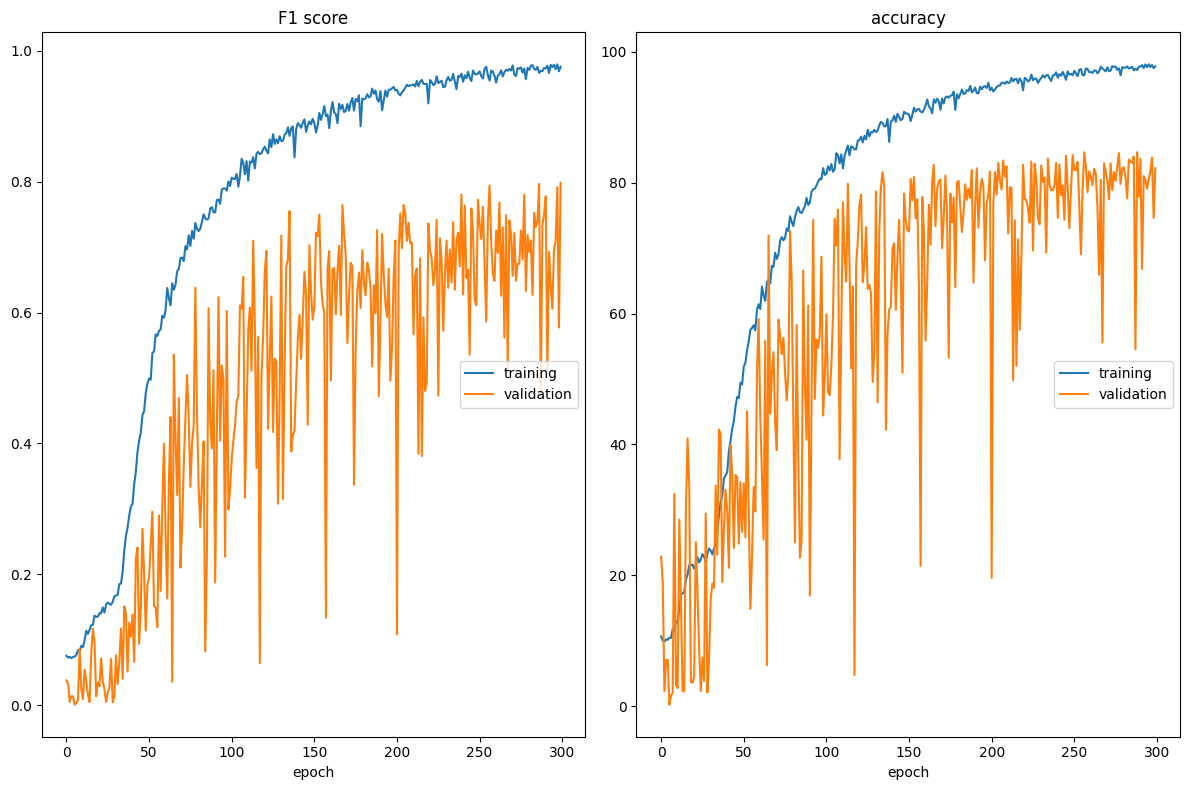

F1 score
	training         	 (min:    0.072, max:    0.979, cur:    0.976)
	validation       	 (min:    0.000, max:    0.798, cur:    0.798)
accuracy
	training         	 (min:    9.859, max:   98.095, cur:   97.779)
	validation       	 (min:    0.223, max:   84.673, cur:   82.217)
train accuracy for this epoch 299 is 97.78%
loss 13569.0059 with epoch time 21.1309 s & computation time 18.3957 s 


In [3]:
logger = train(
    train_dataloader, model, prog_args, val_dataset=test_dataloader, checkpoint=checkpoint
)

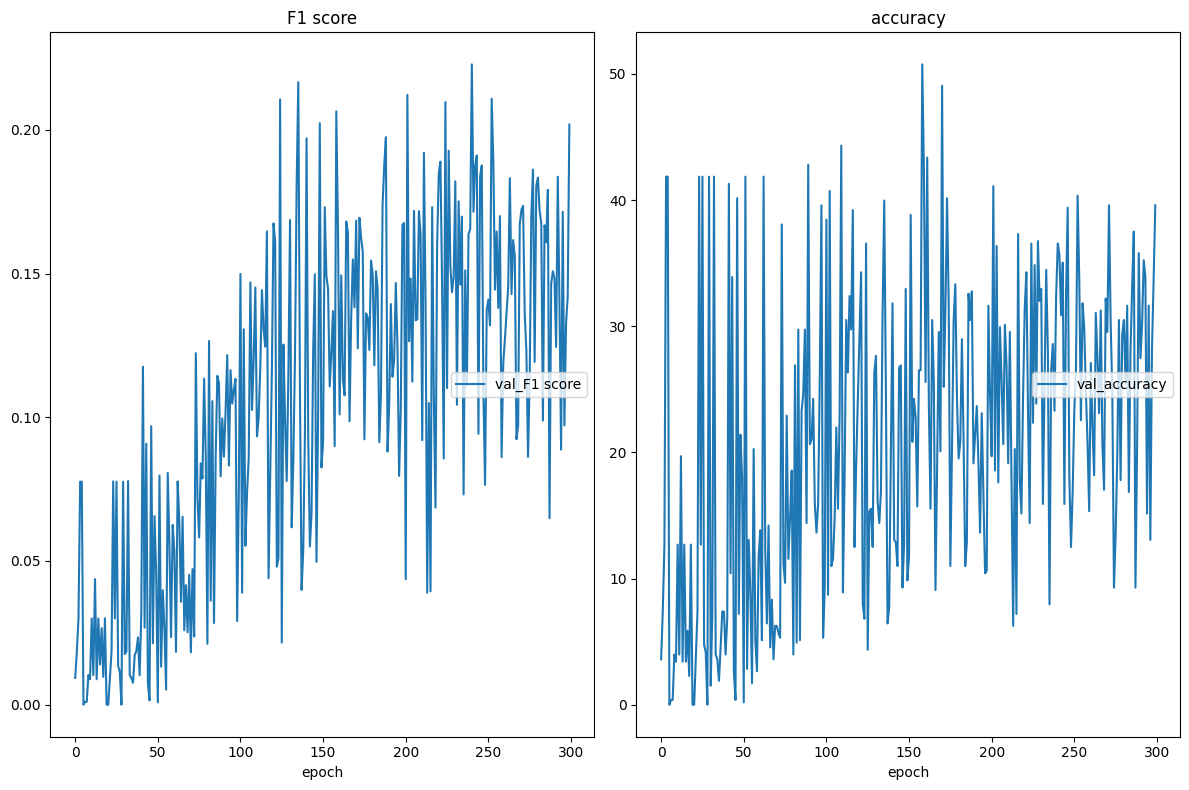

F1 score
	val_F1 score     	 (min:    0.000, max:    0.223, cur:    0.202)
accuracy
	val_accuracy     	 (min:    0.000, max:   50.758, cur:   39.583)


In [4]:
def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_pred_indi = torch.cat((val_pred_indi, torch.tensor([5,7,8], device='cuda')), dim=0)
        val_label_indi = torch.cat((val_label_indi, torch.tensor([6,8,9], device='cuda')), dim=0)
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10

liveloss = PlotLosses()
for i in range(0,300):
    result, val_f1_score, _, _, _, _, _, _, _, _, _, _ = evaluate(realtest_dataloader, model, prog_args, best_epoch=i)
    logs = {} # 实时绘制Loss
    logs['val_accuracy'] = result * 100
    logs['val_F1 score'] = val_f1_score
    liveloss.update(logs)
    liveloss.send()


# # 马后炮评测

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import pandas as pd

sample_redies_udp = 6.0
sample_redies_sugar = 6.0
input_save_dir = 51

# prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.30, num_pool=3, cuda=1, lr=1.0, clip=float("inf"),
#                                batch_size=64, epoch=200, n_worker=2, gc_per_block=3, aggregator_type="meanpool", activation = F.relu, rho = 0.9, eps = 1e-6,
#                                dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_0{input_save_dir}",
#                                load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)

prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=48, epoch=300, n_worker=10, gc_per_block=3, aggregator_type="meanpool", activation = F.relu,
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./model_param_998",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)


def prepare_data(dataset, shuffle=False, prog_args=None):
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )


dataset_train = tu.RhaFinderDataset(name="Rha_Finder",
                                    raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train/')
dataset_test = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/test/')
dataset_realtest = tu.RhaFinderDataset(name="Rha_Finder",
                                       raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)
realtest_dataloader = prepare_data(dataset_realtest, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
input_dim_realtest, label_dim_realtest, max_num_node_realtest = dataset_realtest.statistics()
max_num_node = max([max_num_node_train, max_num_node_test, max_num_node_realtest])
input_dim = input_dim_train
label_dim = label_dim_train
hidden_dim = prog_args.hidden_dim
embedding_dim = prog_args.embedding_dim
assign_dim = int(max_num_node * prog_args.pool_ratio)
activation = prog_args.activation

model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
)

/home/admin123/software/anaconda3/envs/dgl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


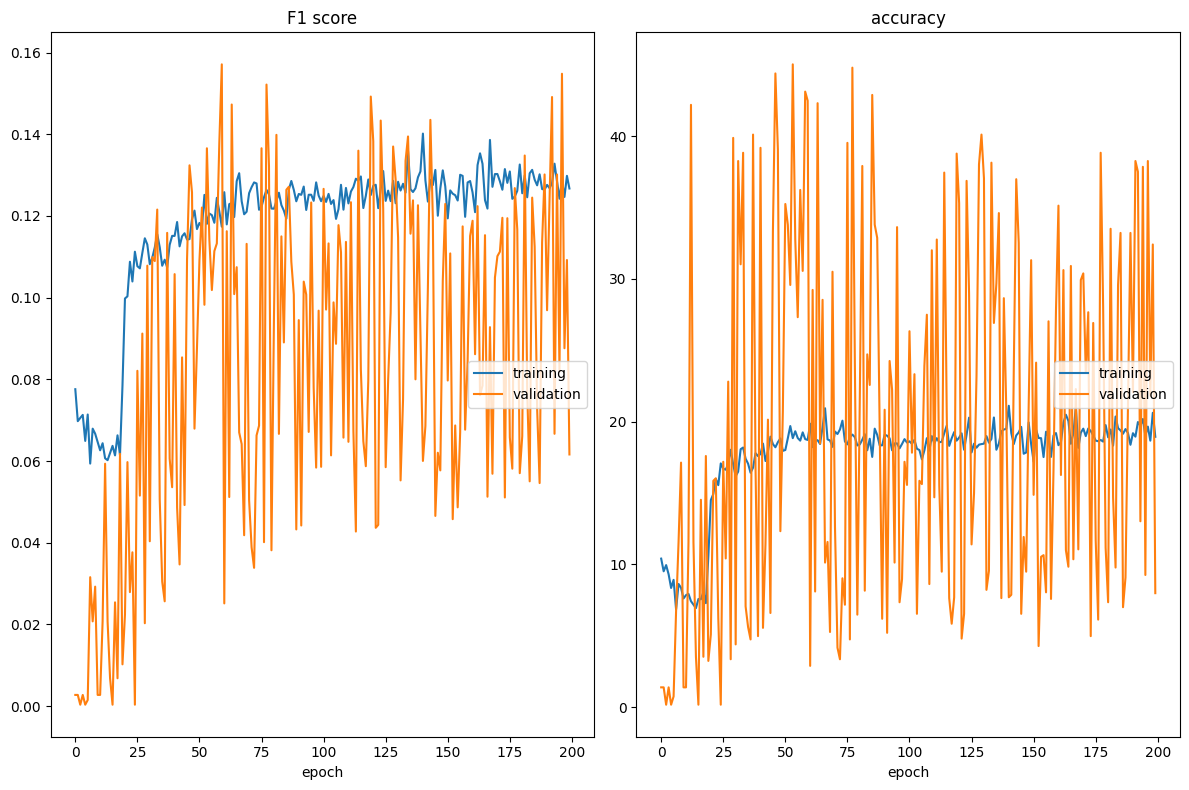

F1 score
	training         	 (min:    0.059, max:    0.140, cur:    0.127)
	validation       	 (min:    0.000, max:    0.157, cur:    0.062)
accuracy
	training         	 (min:    6.853, max:   21.110, cur:   18.938)
	validation       	 (min:    0.174, max:   45.023, cur:    7.986)


In [2]:
df = pd.read_csv(f'./model_param_0{input_save_dir}/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train_log.csv', sep=', ')
liveloss = PlotLosses()
for i in range(len(df)):
    logs = {}  # 实时绘制Loss
    logs['accuracy'] = df['accuracy'][i]
    logs['val_accuracy'] = df['val_accuracy'][i]
    logs['F1 score'] = df['F1 score'][i]
    logs['val_F1 score'] = df['val_F1 score'][i]
    liveloss.update(logs)
    liveloss.send()


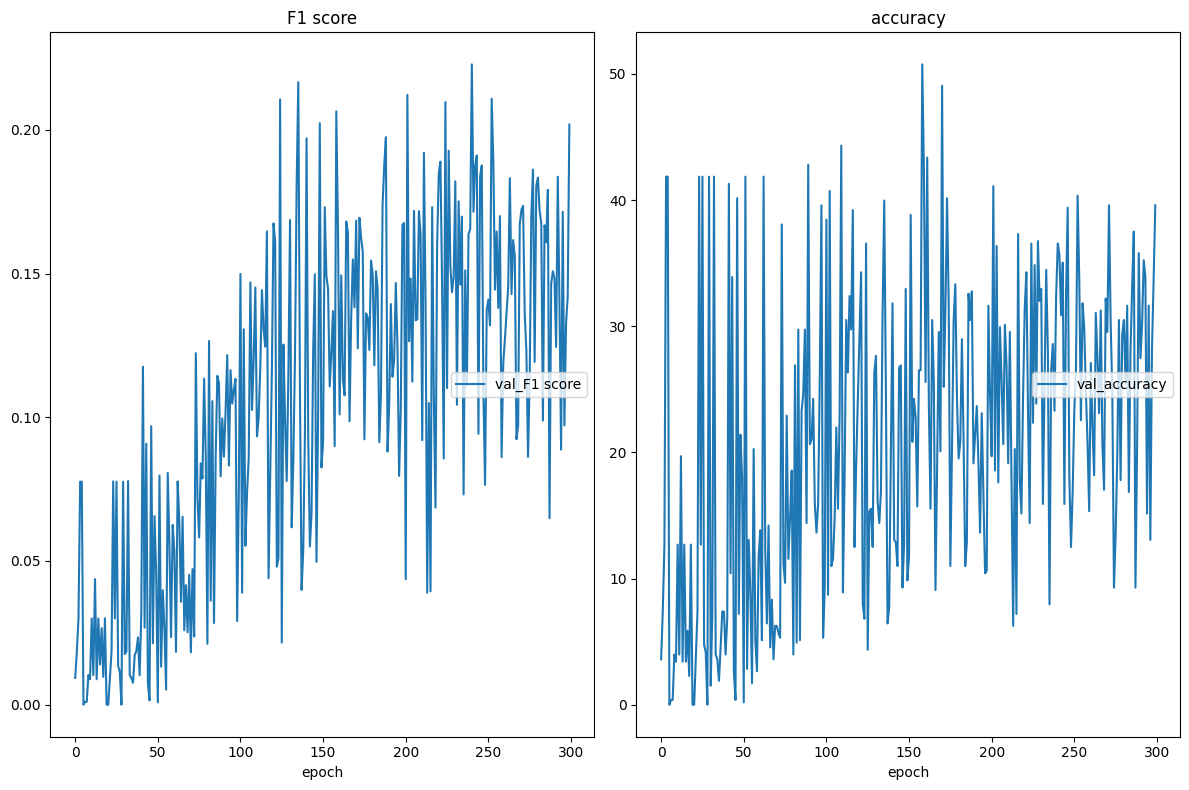

F1 score
	val_F1 score     	 (min:    0.000, max:    0.223, cur:    0.202)
accuracy
	val_accuracy     	 (min:    0.000, max:   50.758, cur:   39.583)


In [2]:
def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_pred_indi = torch.cat((val_pred_indi, torch.tensor([5,7,8], device='cuda')), dim=0)
        val_label_indi = torch.cat((val_label_indi, torch.tensor([6,8,9], device='cuda')), dim=0)
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10

if prog_args.cuda > 0:
    torch.cuda.set_device(0)
if prog_args.cuda:
    model = model.cuda()
for epoch in range(1):
    model.train()
    print("\nGenerate model param ###### ######")
    for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()
        model.zero_grad()
        ypred = model(batch_graph)
    torch.cuda.empty_cache()

liveloss = PlotLosses()
f = open('/home/admin123/work/GTmining/diffpool/model_param_998/Predict_correspond_information.tsv', 'w')
f.write(f"val_accuracy\tval_F1 score\n")
for i in range(0,300):
    result, val_f1_score, _, _, _, _, _, _, _, _, _, _ = evaluate(realtest_dataloader, model, prog_args, best_epoch=i)
    logs = {} # 实时绘制Loss
    logs['val_accuracy'] = result * 100
    logs['val_F1 score'] = val_f1_score
    liveloss.update(logs)
    liveloss.send()
    f.write(f"{result * 100}\t{val_f1_score}\n")

f.close()


测试如何早停

In [8]:
import pandas as pd
from livelossplot import PlotLosses

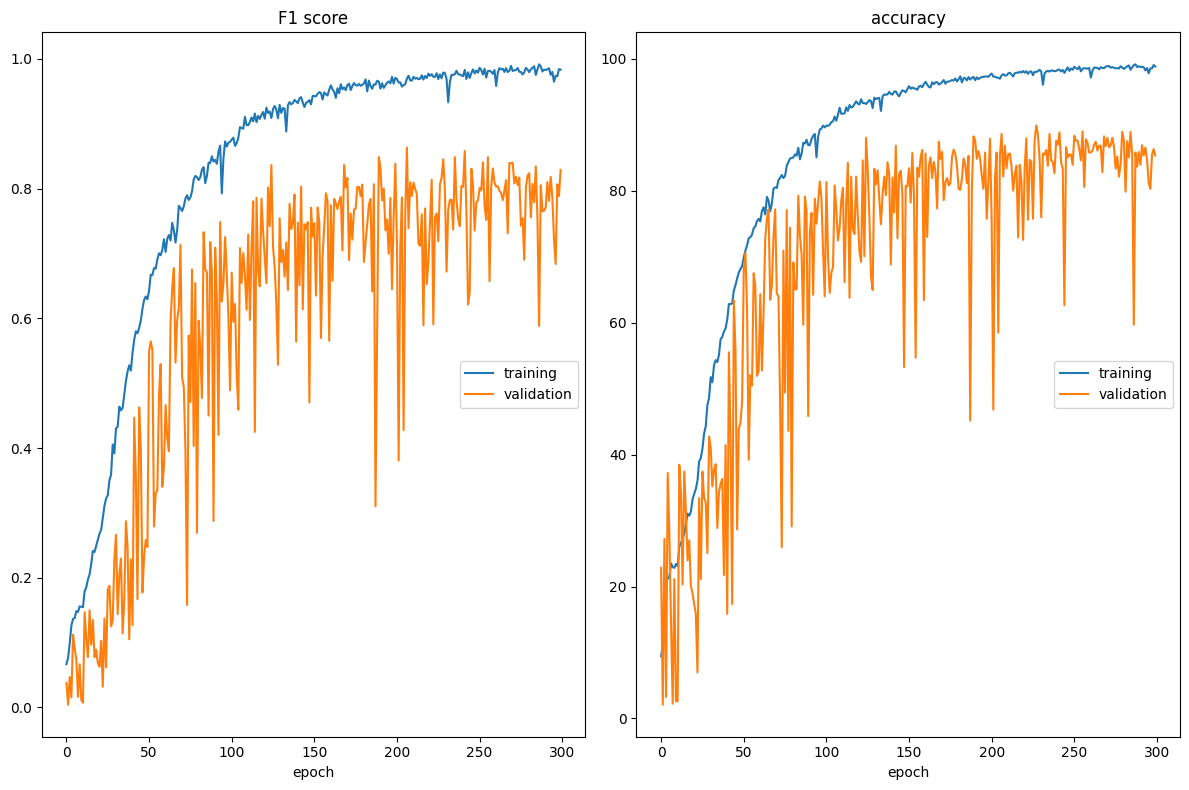

F1 score
	training         	 (min:    0.067, max:    0.992, cur:    0.983)
	validation       	 (min:    0.004, max:    0.863, cur:    0.829)
accuracy
	training         	 (min:    9.450, max:   99.154, cur:   98.839)
	validation       	 (min:    2.083, max:   89.881, cur:   85.342)


In [9]:
df = pd.read_csv(f'./model_param_999/udp6.0_sugar6.0/train_log.csv', sep=', ')
liveloss = PlotLosses()
for i in range(len(df)):
    logs = {}  # 实时绘制Loss
    logs['accuracy'] = df['accuracy'][i]
    logs['val_accuracy'] = df['val_accuracy'][i]
    logs['F1 score'] = df['F1 score'][i]
    logs['val_F1 score'] = df['val_F1 score'][i]
    liveloss.update(logs)
    liveloss.send()

In [10]:
max_F1_val = 0
early_step = 0
for i in range(len(df)):
    if early_step > 25:
        print("Early stop")
        break
    if df['val_F1 score'][i] > max_F1_val:
        max_F1_val = df['val_F1 score'][i]
        early_step = 0
        print("Current max F1 score is", max_F1_val, "at epoch", i)
    else:
        early_step += 1

Current max F1 score is 0.0376687116564417 at epoch 0
Current max F1 score is 0.0468030690537084 at epoch 2
Current max F1 score is 0.1121073452368224 at epoch 4
Current max F1 score is 0.1466168935635727 at epoch 11
Current max F1 score is 0.1497963633813839 at epoch 14
Current max F1 score is 0.1817318795403859 at epoch 25
Current max F1 score is 0.1874771953971645 at epoch 26
Current max F1 score is 0.2285741079917987 at epoch 29
Current max F1 score is 0.266309976792735 at epoch 30
Current max F1 score is 0.2870631070461819 at epoch 36
Current max F1 score is 0.4468004514852207 at epoch 41
Current max F1 score is 0.4626681609182533 at epoch 44
Current max F1 score is 0.5491270627850113 at epoch 50
Current max F1 score is 0.5644286437409287 at epoch 51
Current max F1 score is 0.5945163410037957 at epoch 63
Current max F1 score is 0.646223537181021 at epoch 64
Current max F1 score is 0.6773603904102476 at epoch 65
Current max F1 score is 0.7130410401643787 at epoch 69
Current max F1 

# # 检查loss

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import pandas as pd

sample_redies_udp = 6.0
sample_redies_sugar = 6.0
input_save_dir = 51

prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=48, epoch=300, n_worker=10, gc_per_block=3, aggregator_type="meanpool", activation = F.relu,
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./try_param/model_param_998",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)


def prepare_data(dataset, shuffle=False, prog_args=None):
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )


dataset_train = tu.RhaFinderDataset(name="Rha_Finder",
                                    raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train/')
dataset_test = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/test/')
dataset_realtest = tu.RhaFinderDataset(name="Rha_Finder",
                                       raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)
realtest_dataloader = prepare_data(dataset_realtest, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
input_dim_realtest, label_dim_realtest, max_num_node_realtest = dataset_realtest.statistics()
max_num_node = max([max_num_node_train, max_num_node_test, max_num_node_realtest])
input_dim = input_dim_train
label_dim = label_dim_train
hidden_dim = prog_args.hidden_dim
embedding_dim = prog_args.embedding_dim
assign_dim = int(max_num_node * prog_args.pool_ratio)
activation = prog_args.activation

model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
)

/home/admin123/software/anaconda3/envs/dgl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


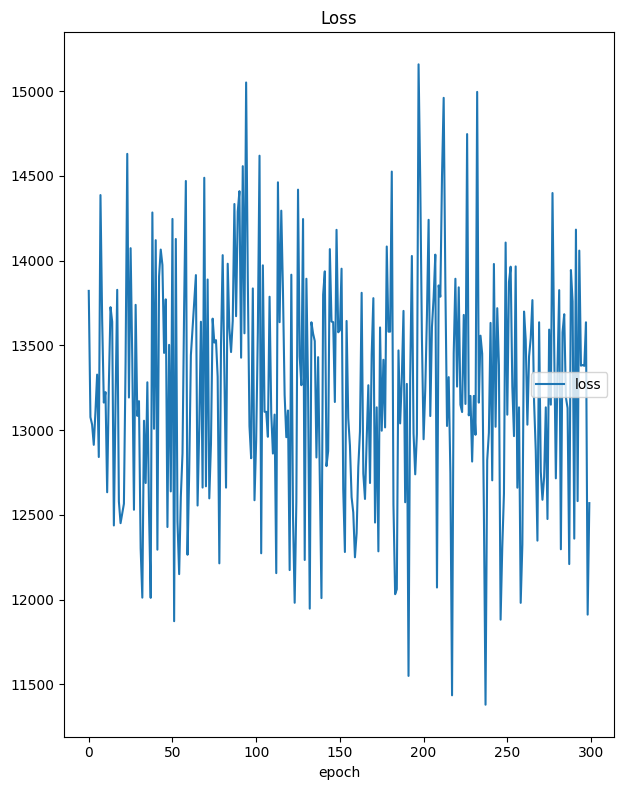

Loss
	loss             	 (min: 11379.374, max: 15158.409, cur: 12569.042)


In [3]:
def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            loss = model.loss(ypred, graph_labels)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_pred_indi = torch.cat((val_pred_indi, torch.tensor([5,7,8], device='cuda')), dim=0)
        val_label_indi = torch.cat((val_label_indi, torch.tensor([6,8,9], device='cuda')), dim=0)
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    # return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10
    return loss

if prog_args.cuda > 0:
    torch.cuda.set_device(0)
if prog_args.cuda:
    model = model.cuda()
for epoch in range(1):
    model.train()
    print("\nGenerate model param ###### ######")
    for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()
        model.zero_grad()
        ypred = model(batch_graph)
    torch.cuda.empty_cache()

liveloss = PlotLosses()
for i in range(0,300):
    loss = evaluate(train_dataloader, model, prog_args, best_epoch=i)
    logs = {} # 实时绘制Loss
    logs['loss'] = loss.cpu()
    liveloss.update(logs)
    liveloss.send()



# 正式预测

In [ ]:
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil

In [ ]:
def prepare_data(dataset, train=False):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    if train:
        shuffle = True
    else:
        shuffle = False

    # dataset.set_fold(fold)
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size, # type: ignore
        shuffle=shuffle,
        num_workers=1,
    )


def train(dataset, model, prog_args, same_feat=True, val_dataset=None):
    """
    training function
    """

    dataloader = dataset
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
    )
    early_stopping_logger = {"best_epoch": -1, "val_F1_score": 0}

    if prog_args.cuda > 0:
        torch.cuda.set_device(0)
    
    for epoch in range(prog_args.epoch):
        train_pred_indi = torch.tensor([], device='cuda:0')
        train_label_indi = torch.tensor([], device='cuda:0')
        begin_time = time.time()
        model.train()
        accum_correct = 0
        total = 0
        print("\nEPOCH ###### {} ######".format(epoch))
        computation_time = 0.0
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()

            model.zero_grad()
            compute_start = time.time()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            train_pred_indi = torch.cat((train_pred_indi, indi), dim=0)
            train_label_indi = torch.cat((train_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels).item()
            accum_correct += correct
            total += graph_labels.size()[0]
            loss = model.loss(ypred, graph_labels)
            train_loss_plot = loss.cpu().detach().numpy()
            loss.backward()
            batch_compute_time = time.time() - compute_start
            computation_time += batch_compute_time
            nn.utils.clip_grad_norm_(model.parameters(), prog_args.clip)
            optimizer.step()
        train_f1_score = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average='macro')
        train_f1_score_class_1, train_f1_score_class_2, train_f1_score_class_3, train_f1_score_class_4, train_f1_score_class_5, train_f1_score_class_6,train_f1_score_class_7, train_f1_score_class_8, train_f1_score_class_9, train_f1_score_class_10 = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average=None)

        train_accu = accum_correct / total

        elapsed_time = time.time() - begin_time

        global_train_time_per_epoch.append(elapsed_time) # type: ignore
        if val_dataset is not None:
            result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = evaluate(val_dataset, model, prog_args)
            print("validation  accuracy {:.2f}%".format(result * 100))


            print(
            "train accuracy for this epoch {} is {:.2f}%".format(
                    epoch, train_accu * 100
                )
            )

            print(
                "loss {:.4f} with epoch time {:.4f} s & computation time {:.4f} s ".format(
                    loss.item(), elapsed_time, computation_time
                )
            )



            print(
                "best epoch is EPOCH {}, val_F1_score is {:.2f}%".format(
                    early_stopping_logger["best_epoch"],
                    early_stopping_logger["val_F1_score"],
                )
            )
        torch.cuda.empty_cache()
    return early_stopping_logger


def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_pred_indi = torch.cat((val_pred_indi, torch.tensor([5,7,8], device='cuda')), dim=0)
        val_label_indi = torch.cat((val_label_indi, torch.tensor([6,8,9], device='cuda')), dim=0)
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
        # val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_7, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
        # val_score_class = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10
    # return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_7, val_f1_score_class_10



In [ ]:
sample_redies_udp = 6.0
sample_redies_sugar = 10.0

global_train_time_per_epoch = []

print("{:=^100}".format('prog_args'))
global_train_time_per_epoch = []
# 初次训练
# prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1e-3, clip=2.0,
#                                batch_size=128, epoch=500, train_ratio=0.7, test_ratio=0.1, n_worker=1, gc_per_block=3,
#                                dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./model_param",
#                                load_epoch=-1, data_mode="default", linkpred=False)
# fine-tune
# prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1e-4, clip=0.5,
#                                batch_size=64, epoch=500, train_ratio=0.7, test_ratio=0.1, n_worker=1, gc_per_block=3,
#                                dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./model_param",
#                                load_epoch=497, data_mode="default", linkpred=False)
# 尝试
prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1e-3, clip=2.0,
                               batch_size=64, epoch=1000, train_ratio=0.7, test_ratio=0.1, n_worker=1, gc_per_block=3,
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./model_param",
                               load_epoch=497, data_mode="default", linkpred=False)
print(prog_args)

print("{:=^100}".format('加载数据'))
dataset_train = tu.RhaFinderDataset(name="Rha_Finder",
                                    raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train/')
dataset_val = tu.RhaFinderDataset(name="Rha_Finder",
                                  raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/val/')
dataset_test = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/test/')
dataset_realtest = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/')
train_dataloader = prepare_data(dataset_train, train=True)
val_dataloader = prepare_data(dataset_val, train=False)
test_dataloader = prepare_data(dataset_test, train=False)
realtest_dataloader = prepare_data(dataset_realtest, train=False)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_val, label_dim_val, max_num_node_val = dataset_val.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_val, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_val))

hidden_dim = 64  # used to be 64
embedding_dim = 64

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    "meanpool",
    assign_dim,
    prog_args.pool_ratio,
)

if prog_args.load_epoch >= 0 and prog_args.save_dir is not None:
    if prog_args.cuda > 0:
        torch.cuda.set_device(0)
        model = model.cuda()
    for epoch in range(1):
        model.train()
        print("\nGenerate model param ###### ######")
        for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            model.zero_grad()
            ypred = model(batch_graph)
        torch.cuda.empty_cache()

    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(prog_args.load_epoch)
        )
    )

print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

In [ ]:
ff = open('./test_F1.csv', 'w')
ff.write("{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}\n".format('epoch', 'val_accuracy', 'val_F1 score',
                                                                       'val_Class 1 F1 score', 'val_Class 2 F1 score',
                                                                       'val_Class 3 F1 score', 'val_Class 4 F1 score',
                                                                       'val_Class 5 F1 score', 'val_Class 6 F1 score',
                                                                       'val_Class 7 F1 score', 'val_Class 8 F1 score',
                                                                       'val_Class 9 F1 score', 'val_Class 10 F1 score'))
for i in range(0,1000):
    result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = evaluate(realtest_dataloader, model, prog_args, best_epoch=i)
    ff.write("{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}\n".format(i, result * 100, val_f1_score,
                                                                           val_f1_score_class_1, val_f1_score_class_2,
                                                                           val_f1_score_class_3, val_f1_score_class_4,
                                                                           val_f1_score_class_5, val_f1_score_class_6,
                                                                           val_f1_score_class_7,  val_f1_score_class_8,
                                                                           val_f1_score_class_9, val_f1_score_class_10))
ff.close()


In [ ]:
i

In [ ]:
evaluate(realtest_dataloader, model, prog_args, best_epoch=497)

In [ ]:
model.load_state_dict(
    torch.load(
        prog_args.save_dir
        + "/"
        + prog_args.dataset
        + "/model.iter-"
        + "{:04d}".format(2)
    )
)
model.eval()
correct_label = 0
with torch.no_grad():
    val_pred_indi = torch.tensor([], device='cuda')
    val_label_indi = torch.tensor([], device='cuda')
    for batch_idx, (batch_graph, graph_labels) in enumerate(realtest_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()
        ypred = model(batch_graph)
        indi = torch.argmax(ypred, dim=1)
        val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
        val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
        correct = torch.sum(indi == graph_labels)
        correct_label += correct.item()
    val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
    # val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_7, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    val_score_class = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
result = correct_label / (len(realtest_dataloader) * prog_args.batch_size)

In [ ]:
f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)

In [ ]:
for l, p in zip(val_label_indi.cpu(), val_pred_indi.cpu()):
    print(int(l), int(p))

In [ ]:
val_label_indi.cpu()

In [ ]:
result, val_f1_score

In [ ]:
val_pred_indi, val_label_indi